# **Analyzing Impact of Teacher Attributes on Student Evaluation**


## Hypothesis Testing


The goal of hypothesis testing is to answer the question, “Given a sample and an apparent effect, what is the probability of seeing such an effect by chance?” The first step is to quantify the size of the apparent effect by choosing a test statistic (t-test, ANOVA, etc). The next step is to define a null hypothesis, which is a model of the system based on the assumption that the apparent effect is not real. Then compute the p-value, which is the probability of the null hypothesis being true, and finally interpret the result of the p-value, if the value is low, the effect is said to be statistically significant, which means that the null hypothesis may not be accurate.

### Objectives


*   Import Libraries
*   Stating the hypothesis
*   Levene's Test for equality
*   Preparing your data for hypothesis testing

***


#### Importing Libraries


Importing the libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats

In [2]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv'
ratings_df = pd.read_csv(URL)

#### T-Test: Does gender affect teaching evaluation rates?


I used the t-test for independent samples. For the independent t-test, the following assumptions must be met.

*   One independent, categorical variable with two levels or group
*   One dependent continuous variable
*   Independence of the observations. Each subject should belong to only one group. There is no relationship between the observations in each group.
*   The dependent variable must follow a normal distribution
*   Assumption of homogeneity of variance


Stating the hypothesis

*   $H\_0: µ\_1 = µ\_2$ ( there is no difference in evaluation scores between male and females )
*   $H\_1: µ\_1 ≠ µ\_2$ ( there is a difference in evaluation scores between male and females )


Ploting the dependent variable with a historgram


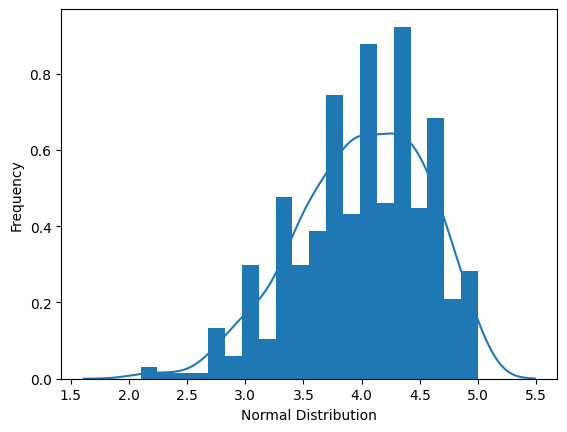

In [12]:
import warnings
warnings.filterwarnings("ignore")
ax = sns.distplot(ratings_df['eval'],
                  bins=20,
                  kde=True,
                  hist_kws={"linewidth": 15,'alpha':1})
ax.set(xlabel='Normal Distribution', ylabel='Frequency');

Using the Levene's Test to check test significance


In [18]:
scipy.stats.levene(ratings_df[ratings_df['gender'] == 'female']['eval'],
                   ratings_df[ratings_df['gender'] == 'male']['eval'], center='mean').pvalue.item(0)

0.6628469836244741

Since the p-value is greater than 0.05, we can assume equality of variance

Use the <code>ttest_ind</code> from the <code>scipy_stats</code> library


In [23]:
statistic, p_value= scipy.stats.ttest_ind(ratings_df[ratings_df['gender'] == 'female']['eval'],
                   ratings_df[ratings_df['gender'] == 'male']['eval'], equal_var = True)

print(round(p_value, 5))

0.00124


**Conclusion:** Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that there is a statistical difference in teaching evaluations based on gender


### ANOVA: Does beauty  score for instructors  differ by age?

First, I grouped the data into cateries as the one-way ANOVA can't work with continuous variable. I created a new column for this newly assigned group:

*   40 years and younger
*   between 40 and 57 years
*   57 years and older


In [24]:
ratings_df.loc[(ratings_df['age'] <= 40), 'age_group'] = '40 years and younger'
ratings_df.loc[(ratings_df['age'] > 40)&(ratings_df['age'] < 57), 'age_group'] = 'between 40 and 57 years'
ratings_df.loc[(ratings_df['age'] >= 57), 'age_group'] = '57 years and older'

Stating the hypothesis

*   $H\_0: µ\_1 = µ\_2 = µ\_3$ ( the three population means are equal )
*   $H\_1:$ At least one of the means differ

Test for equality of variance


In [ ]:
scipy.stats.levene(ratings_df[ratings_df['age_group'] == '40 years and younger']['beauty'],
                   ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['beauty'], 
                   ratings_df[ratings_df['age_group'] == '57 years and older']['beauty'], 
                   center='mean')


Since the p-value is less than 0.05, the variance are not equal, however, I still used it for practice

First, separating the three samples (one for each job category) into a variable each.

In [25]:
forty_lower = ratings_df[ratings_df['age_group'] == '40 years and younger']['beauty']
forty_fiftyseven = ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['beauty']
fiftyseven_older = ratings_df[ratings_df['age_group'] == '57 years and older']['beauty']

Now, runing a one-way ANOVA.


In [28]:
f_statistic, p_value = scipy.stats.f_oneway(forty_lower, forty_fiftyseven, fiftyseven_older)
print("F_Statistic: {0}, P-Value: {1}".format(round(f_statistic, 3), round(p_value, 5)))

F_Statistic: 17.598, P-Value: 0.0


**Conclusion:** Since the p-value is less than 0.05, we will reject the null hypothesis as there is significant evidence that at least one of the means differ.


### ANOVA: Does teaching  evaluation  score for instructors  differ  by age?


Test for equality of variance


In [32]:
levene_test, p_value = scipy.stats.levene(ratings_df[ratings_df['age_group'] == '40 years and younger']['eval'],
                   ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['eval'], 
                   ratings_df[ratings_df['age_group'] == '57 years and older']['eval'], 
                   center='mean')

print("Levene Test P-value: ", round(p_value, 3))

if p_value < 0.05:
    print("Reject the null hypothesis: The variances are not equal.")
else:
    print("Fail to reject the null hypothesis: The variances are equal.")

Levene Test P-value:  0.023
Reject the null hypothesis: The variances are not equal.


In [33]:
forty_lower_eval = ratings_df[ratings_df['age_group'] == '40 years and younger']['eval']
forty_fiftyseven_eval = ratings_df[ratings_df['age_group'] == 'between 40 and 57 years']['eval']
fiftyseven_older_eval = ratings_df[ratings_df['age_group'] == '57 years and older']['eval']

In [37]:
f_statistic, p_value = scipy.stats.f_oneway(forty_lower_eval, forty_fiftyseven_eval, fiftyseven_older_eval)
print("F_Statistic: {0}, P-Value: {1}".format(round(f_statistic, 3), round(p_value, 3)))

F_Statistic: 1.223, P-Value: 0.295


**Conclusion:** Since the p-value is greater than 0.05, we fail to reject the null hypothesis as there is no significant evidence that at least one of the means differ.


### Chi-square: Is there an association between tenure and gender?


Stating the hypothesis:

*   $H\_0:$ The proportion of teachers who are tenured is independent of gender
*   $H\_1:$ The proportion of teachers who are tenured is associated with gender


Creating a Cross-tab table


In [38]:
cont_table  = pd.crosstab(ratings_df['tenure'], ratings_df['gender'])
cont_table

gender,female,male
tenure,,
no,50,52
yes,145,216


Using the <code>scipy.stats</code> library. Seting the correction equals False as that will be the same answer when done by hand, it returns: 𝜒2 value, p-value, degree of freedom, and expected values.


In [40]:
chi2_statistic, p_value, dof, expected = scipy.stats.chi2_contingency(cont_table, correction = False)
print("Chi2_Statistic: {0}, P-Value: {1}".format(round(chi2_statistic, 3), round(p_value, 3)))

Chi2_Statistic: 2.557, P-Value: 0.11


**Conclusion:** Since the p-value is greater than 0.05, we fail to reject the null hypothesis. As there is no sufficient evidence that teachers are tenured as a result of gender.


### Correlation: Is teaching  evaluation  score correlated with  beauty score?


Stating the hypothesis:

*   $H\_0:$ Teaching evaluation score is not correlated with beauty score
*   $H\_1:$ Teaching evaluation score is correlated with beauty score


Since they are both continuous variables, I used a pearson correlation test and drew a scatter plot


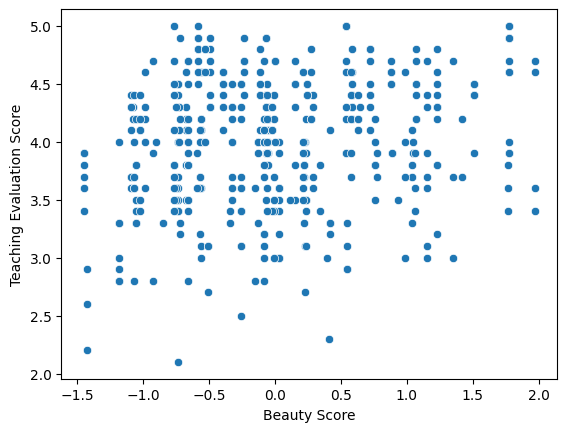

In [41]:
ax = sns.scatterplot(x="beauty", y="eval", data=ratings_df)
ax.set(xlabel='Beauty Score', ylabel='Teaching Evaluation Score')
plt.show();

In [44]:
statistic, p_value = scipy.stats.pearsonr(ratings_df['beauty'], ratings_df['eval'])
print("Pearson correlation statistic: ", round(statistic, 3))
print("P-value: ", round(p_value, 3))


Pearson correlation statistic:  0.189
P-value:  0.0


**Conclusion:** Since the p-value  (Sig. 2-tailed)  < 0.05, we reject  the Null hypothesis and conclude that there  exists a relationship between  beauty and teaching evaluation score.


### Does tenure affect teaching evaluation scores?

*   Using α = 0.05

Null Hypothesis (H0): Tenure does not affect teaching evaluation scores.

Alternative Hypothesis (H1): Tenure does affect teaching evaluation scores.


In [47]:
statistic, p_value = scipy.stats.ttest_ind(ratings_df[ratings_df['tenure'] == 'yes']['eval'],
                   ratings_df[ratings_df['tenure'] == 'no']['eval'], equal_var = True)

print("T-statistic: ", round(statistic, 3))
print("P-value: ", round(p_value, 3))

T-statistic:  -2.805
P-value:  0.005



**Conclusion:** Since the p-value is less than 0.05, we will reject the null hypothesis as there evidence that being tenured affects teaching evaluation scores


### Is there an association between age and tenure?

*   Geting the conclusion at α = 0.01 and α = 0.05

Null Hypothesis: There is no association between age and tenure

Alternative Hypothesis: There is an association between age and tenure


In [50]:
cont_table  = pd.crosstab(ratings_df['tenure'], ratings_df['age_group'])
cont_table


age_group,40 years and younger,57 years and older,between 40 and 57 years
tenure,,,
no,15,25,62
yes,98,97,166


In [53]:
statistic, p_value, dof, expected = scipy.stats.chi2_contingency(cont_table)
print("statistic: ", round(statistic, 3))
print("p-value: ", round(p_value, 3)) 

statistic:  8.75
p-value:  0.013


**Conclusion:**
- At the α = 0.01, p-value is greater, we fail to reject null hypothesis as there is no evidence of an association between age and tenure
- At the α = 0.05, p-value is less, we reject null hypoothesis as there is evidence of an association between age and tenure

### Test for equality of variance for beauty scores between tenured and non-tenured instructors

*   Using α = 0.05

Null Hypothesis: The variance of beauty scores between tenured and non-tenured instructors is equal

Alternative Hypothesis: The variance of beauty scores between tenured and non-tenured instructors is not equal


In [56]:
statistic, p_value = scipy.stats.levene(ratings_df[ratings_df['tenure'] == 'yes']['beauty'],
                   ratings_df[ratings_df['tenure'] == 'no']['beauty'], 
                   center='mean')

print("Levene Test Statistic:", round(statistic, 3))
print("p-value:", round(p_value, 3))

Levene Test Statistic: 0.488
p-value: 0.485


**Conclusion:** Since the p-value is greater than 0.05, we can assume equality of variance of both groups


### Is there an association between visible minorities and tenure?

*   Using α = 0.05

Null Hypothesis (H0): There is no association between visible minorities and tenure

Alternative Hypothesis (H1): There is an association between visible minorities and tenure



In [57]:
cont_table  = pd.crosstab(ratings_df['vismin'], ratings_df['tenure'])
cont_table

tenure,no,yes
vismin,,
0,92,307
1,10,54


In [59]:
statistic, p_value, dof, expected = scipy.stats.chi2_contingency(cont_table, correction = True)
print("statistic = ", round(statistic, 3))
print("p_value = ", round(p_value, 3))

statistic =  1.368
p_value =  0.242


**Conclusion:** Since the p-value is greater than 0.05, we fail to reject null hypothesis as there is no evidence of an association between visible minorities and tenure.


---

## Author

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)
